# PEPSI legacy line-window validation with PHOENIX

This notebook validates a PEPSI line-window workflow using the same multi-segment infrastructure used elsewhere in Spyctres.

The shared infrastructure is:

- `SpectrumSegment` for individual spectral windows
- `SpectrumCollection` for a joint fit over several windows
- one shared PHOENIX parameter set across all selected segments
- native-grid PHOENIX forward modelling
- wavelength-medium handling
- instrumental broadening
- PHOENIX interpolation caching

The fit is still a multi-segment PHOENIX fit: several `SpectrumSegment`s are combined in a `SpectrumCollection`, one shared set of stellar parameters is fitted across all windows, and the PHOENIX model is evaluated through the same native-grid forward-model machinery used elsewhere in Spyctres.

The PEPSI-specific part is the local normalization used inside each narrow line window. For this validation case, each model window is normalized by its local maximum before comparison to the normalized PEPSI data, with a fitted error-scale nuisance parameter. This matches the legacy PEPSI line-window workflow more closely than a generic continuum correction over broader spectral regions.

This notebook is therefore not a separate general classification recipe. It is a validation notebook showing that the same multi-segment infrastructure can support the PEPSI legacy line-window analysis in a modular way.

## Workflow

1. Locate the PHOENIX templates and PEPSI example spectra.
2. Read the PEPSI files into `SpectrumSegment` objects.
3. Build PEPSI legacy line-window segments.
4. Wrap those windows in a `SpectrumCollection`.
5. Build or load the PHOENIX interpolation cache.
6. Define a compact notebook-level objective for the legacy PEPSI likelihood.
7. Run a fast validation fit.
8. Plot the fitted line windows and inspect the result.

In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"pkg_resources is deprecated as an API.*",
    category=UserWarning,
    module=r"pysynphot.*",
)

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
# Make sure the notebook imports the local development checkout, not an older
# installed Spyctres package from site-packages.

import sys
from pathlib import Path

cwd = Path.cwd().resolve()

if (cwd / "Spyctres").exists():
    repo_root = cwd
elif (cwd.parent / "Spyctres").exists():
    repo_root = cwd.parent
else:
    # Adjust this only if you run the notebook from somewhere unusual.
    repo_root = Path("~/Installed_Programs/Spyctres-dev").expanduser().resolve()

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Using repo root:", repo_root)

Using repo root: /home/Tux/ytsapras/Installed_Programs/Spyctres-dev


In [3]:
from Spyctres import Spyctres
from Spyctres.config import load_user_config, get_config_value, resolve_setting
from Spyctres.io import read_spectrum, SpectrumCollection
from Spyctres.phoenix import PhoenixLibrary
from Spyctres.plotting import plot_full_spectrum_fit

from Spyctres.recipes import (
    build_pepsi_legacy_segments,
    make_pepsi_legacy_cache_support_segments,
    ensure_phoenix_native_interpolator_for_segments,
    pick_grid_range,
    evaluate_pepsi_legacy_max_models,
    pepsi_legacy_max_likelihood_terms,
)

## Locate PHOENIX and the PEPSI example spectra

The PHOENIX template directory is read from the same configuration system used by the scripts:

1. `SPYCTRES_PHOENIX_DIR`
2. `~/.config/spyctres/config.toml`

The notebook can be run either from the repository root or from the `examples/` directory.

In [4]:
# Locate the local PHOENIX template directory.

config = load_user_config()
phoenix_dir_cfg = get_config_value(config, "paths", "phoenix_dir", default=None)

phoenix_dir = resolve_setting(
    None,
    env_var_name="SPYCTRES_PHOENIX_DIR",
    config_value=phoenix_dir_cfg,
    default=None,
)

if phoenix_dir is None:
    raise RuntimeError(
        "No PHOENIX directory found. Set SPYCTRES_PHOENIX_DIR or configure "
        "~/.config/spyctres/config.toml."
    )

phoenix_dir = Path(phoenix_dir).expanduser().resolve()

if not phoenix_dir.exists():
    raise FileNotFoundError(f"PHOENIX directory does not exist: {phoenix_dir}")

# Locate example data. This works if the notebook is run from the repo root
# or from the examples/ directory.

cwd = Path.cwd().resolve()

if (cwd / "examples" / "data").exists():
    data_dir = cwd / "examples" / "data"
elif (cwd / "data").exists():
    data_dir = cwd / "data"
else:
    raise FileNotFoundError(
        "Could not find the example data directory. Run this notebook from "
        "the repo root or from the examples/ directory."
    )

pepsi_blue_path = data_dir / "pepsib.20230603.014.dxt.nor"
pepsi_red1_path = data_dir / "pepsir.20230603.009.dxt.nor"
pepsi_red2_path = data_dir / "pepsir.20230603.010.dxt.nor"

pepsi_paths = [pepsi_red1_path, pepsi_red2_path]

for path in pepsi_paths:
    if not path.exists():
        raise FileNotFoundError(path)

print("PHOENIX dir:", phoenix_dir)
print("Data dir   :", data_dir)
print("PEPSI files used in this validation:")
for path in pepsi_paths:
    print(" ", path.name)

if pepsi_blue_path.exists():
    print("Blue PEPSI file available but not used in the default red-window validation:")
    print(" ", pepsi_blue_path.name)

PHOENIX dir: /home/Tux/ytsapras/Installed_Programs/astroARIADNE/Models_Dir/PHOENIXv2
Data dir   : /home/Tux/ytsapras/Installed_Programs/Spyctres-dev/examples/data
PEPSI files used in this validation:
  pepsir.20230603.009.dxt.nor
  pepsir.20230603.010.dxt.nor
Blue PEPSI file available but not used in the default red-window validation:
  pepsib.20230603.014.dxt.nor


In [5]:
def print_table(rows, columns=None, float_formats=None):
    """
    Print a compact plain-text table.

    This avoids adding a pandas dependency for simple notebook diagnostics.
    """
    if rows is None or len(rows) == 0:
        print("(no rows)")
        return

    if columns is None:
        columns = list(rows[0].keys())

    float_formats = {} if float_formats is None else dict(float_formats)

    def format_value(col, value):
        if isinstance(value, (float, np.floating)):
            fmt = float_formats.get(col, None)
            return format(value, fmt) if fmt is not None else str(float(value))
        return str(value)

    str_rows = [
        [format_value(col, row.get(col, "")) for col in columns]
        for row in rows
    ]

    widths = [
        max(len(str(col)), max(len(r[j]) for r in str_rows))
        for j, col in enumerate(columns)
    ]

    header = " | ".join(str(col).ljust(widths[j]) for j, col in enumerate(columns))
    sep = "-+-".join("-" * widths[j] for j in range(len(columns)))

    print(header)
    print(sep)
    for r in str_rows:
        print(" | ".join(r[j].ljust(widths[j]) for j in range(len(columns))))

In [6]:
def concat_with_gap(arrays, gap_value=np.nan, dtype=float):
    """
    Concatenate arrays with one separator element between segments.

    The separator creates visible gaps in plots, so separate PEPSI line windows
    are not connected by artificial lines.
    """
    arrays = [np.asarray(a, dtype=dtype) for a in arrays]
    if len(arrays) == 0:
        return np.array([], dtype=dtype)

    out = []
    for i, arr in enumerate(arrays):
        out.append(arr)
        if i < len(arrays) - 1:
            out.append(np.array([gap_value], dtype=dtype))

    return np.concatenate(out)


def concat_bool_with_gap(arrays):
    """Concatenate boolean masks with a False separator between segments."""
    return concat_with_gap(arrays, gap_value=False, dtype=bool)

## Read the PEPSI spectra

We read the two red PEPSI `.dxt.nor` files into `SpectrumSegment` objects.

The PEPSI reader stores useful metadata in each segment, including the object name, wavelength convention, wavelength frame, resolving power, and the `SSBVEL` keyword when available. We keep the original files as full-arm segments first, then build the smaller line-window segments in the next step.

In [7]:
# Read the two red PEPSI spectra.

raw_segments = []

for path in pepsi_paths:
    seg = read_spectrum(path, instrument="pepsi")

    # Preserve the source filename in metadata so later window segments can
    # report which PEPSI file they came from.
    meta = dict(seg.meta)
    meta["source_file"] = str(path)
    raw_segments.append(seg.copy(meta=meta))

summary_rows = []
for seg in raw_segments:
    summary_rows.append(
        {
            "name": Path(seg.meta.get("source_file", seg.name)).name,
            "object": seg.meta.get("object"),
            "n_pix": len(seg.wave),
            "wave_min_A": float(np.nanmin(seg.wave)),
            "wave_max_A": float(np.nanmax(seg.wave)),
            "wave_medium": seg.wave_medium,
            "wave_frame": seg.wave_frame,
            "resolution_R": seg.meta.get("resolution_R"),
            "ssbvel_mps": seg.meta.get("ssbvel_mps"),
        }
    )

print_table(
    summary_rows,
    columns=[
        "name",
        "object",
        "n_pix",
        "wave_min_A",
        "wave_max_A",
        "wave_medium",
        "wave_frame",
        "resolution_R",
        "ssbvel_mps",
    ],
    float_formats={
        "wave_min_A": ".1f",
        "wave_max_A": ".1f",
        "resolution_R": ".1f",
        "ssbvel_mps": ".1f",
    },
)

name                        | object    | n_pix | wave_min_A | wave_max_A | wave_medium | wave_frame | resolution_R | ssbvel_mps
----------------------------+-----------+-------+------------+------------+-------------+------------+--------------+-----------
pepsir.20230603.009.dxt.nor | Gaia21dnc | 17382 | 6235.6     | 7432.4     | unknown     | unknown    | 50000.0      | -23246.5  
pepsir.20230603.010.dxt.nor | Gaia21dnc | 21333 | 7356.2     | 9069.6     | unknown     | unknown    | 50000.0      | -23165.1  


## Build PEPSI legacy line-window segments

The stored PEPSI wavelength convention is marked as unknown by the reader. In the PEPSI red-window tests, the coherent solution was obtained by treating the stored wavelengths as air wavelengths. We therefore set `wave_hypothesis = "air"` for this validation.

In [8]:
# PEPSI legacy-window setup.

wave_hypothesis = "air"

legacy_centers_air = None      # None uses the recipe default: 6495, 6545, 6561, 8498, 8542, 8662 Å
legacy_halfwidth_A = 10.0
legacy_flux_min = 0.2
legacy_flux_max = 1.1
window_pad_A = 2.0

input_segments, fit_segments, window_defs_air = build_pepsi_legacy_segments(
    raw_segments,
    wave_hypothesis=wave_hypothesis,
    centers_air=legacy_centers_air,
    halfwidth_A=legacy_halfwidth_A,
    flux_min=legacy_flux_min,
    flux_max=legacy_flux_max,
    window_pad_A=window_pad_A,
)

print("Legacy windows defined in air:")
for label, wmin, wmax in window_defs_air:
    print(" ", label, (wmin, wmax))

print("\nFitted window segments:")
for seg in fit_segments:
    working = seg.meta.get("legacy_window_working", None)
    medium = seg.meta.get("legacy_window_medium", seg.wave_medium)
    print(
        " ",
        seg.name,
        "| source:",
        Path(seg.meta.get("source_file", "")).name,
        "| N fit pixels:",
        int(np.sum(seg.mask)),
        "| working medium:",
        medium,
        "| working window:",
        None if working is None else working[1:],
    )

Legacy windows defined in air:
  legacy_6495.0 (6485.0, 6505.0)
  legacy_6545.0 (6535.0, 6555.0)
  legacy_6561.0 (6551.0, 6571.0)
  legacy_8498.0 (8488.0, 8508.0)
  legacy_8542.0 (8532.0, 8552.0)
  legacy_8662.0 (8652.0, 8672.0)

Fitted window segments:
  legacy_6495.0 | source: pepsir.20230603.009.dxt.nor | N fit pixels: 288 | working medium: air | working window: (6485.0, 6505.0)
  legacy_6545.0 | source: pepsir.20230603.009.dxt.nor | N fit pixels: 262 | working medium: air | working window: (6535.0, 6555.0)
  legacy_6561.0 | source: pepsir.20230603.009.dxt.nor | N fit pixels: 277 | working medium: air | working window: (6551.0, 6571.0)
  legacy_8498.0 | source: pepsir.20230603.010.dxt.nor | N fit pixels: 202 | working medium: air | working window: (8488.0, 8508.0)
  legacy_8542.0 | source: pepsir.20230603.010.dxt.nor | N fit pixels: 218 | working medium: air | working window: (8532.0, 8552.0)
  legacy_8662.0 | source: pepsir.20230603.010.dxt.nor | N fit pixels: 199 | working medium:

## Apply the telluric mask and build the SpectrumCollection

The PEPSI red-window smoke test uses Spyctres' built-in telluric mask. The mask function can return float-like values, so we explicitly convert it to a boolean mask before using it for indexing.

After masking, the fitted windows are wrapped in a `SpectrumCollection` with unit weights.

In [9]:
# Apply telluric masking to the fitted PEPSI line-window segments.

telluric_threshold = 0.90
_, telluric_mask = Spyctres.load_telluric_lines(telluric_threshold)

def pepsi_telluric_bad_mask(wave):
    """Return True for wavelengths excluded by the telluric mask."""
    return np.asarray(telluric_mask(wave)) > 0.5

fit_segments_masked = [
    seg.copy(
        mask=np.asarray(seg.mask, dtype=bool) & ~pepsi_telluric_bad_mask(seg.wave)
    )
    for seg in fit_segments
]

collection = SpectrumCollection(
    segments=fit_segments_masked,
    weights=np.ones(len(fit_segments_masked), dtype=float),
    meta={
        "instrument": "PEPSI",
        "mode": "legacy_max",
        "wave_hypothesis": wave_hypothesis,
        "legacy_windows_air": list(window_defs_air),
        "telluric_threshold": telluric_threshold,
        "legacy_flux_range": (legacy_flux_min, legacy_flux_max),
    },
    name="pepsi_legacy_windows",
)

collection_rows = []
for seg, weight in zip(collection.segments, collection.weights):
    collection_rows.append(
        {
            "segment": seg.name,
            "source": Path(seg.meta.get("source_file", "")).name,
            "n_fit": int(np.sum(seg.mask)),
            "weight": float(weight),
            "wave_min_A": float(np.nanmin(seg.wave)),
            "wave_max_A": float(np.nanmax(seg.wave)),
        }
    )

print("Collection:", collection.name)
print("Number of segments:", len(collection))
print_table(
    collection_rows,
    columns=["segment", "source", "n_fit", "weight", "wave_min_A", "wave_max_A"],
    float_formats={
        "weight": ".2f",
        "wave_min_A": ".1f",
        "wave_max_A": ".1f",
    },
)

Collection: pepsi_legacy_windows
Number of segments: 6
segment       | source                      | n_fit | weight | wave_min_A | wave_max_A
--------------+-----------------------------+-------+--------+------------+-----------
legacy_6495.0 | pepsir.20230603.009.dxt.nor | 283   | 1.00   | 6483.0     | 6507.0    
legacy_6545.0 | pepsir.20230603.009.dxt.nor | 259   | 1.00   | 6533.1     | 6557.0    
legacy_6561.0 | pepsir.20230603.009.dxt.nor | 276   | 1.00   | 6549.1     | 6572.9    
legacy_8498.0 | pepsir.20230603.010.dxt.nor | 202   | 1.00   | 8486.1     | 8510.0    
legacy_8542.0 | pepsir.20230603.010.dxt.nor | 218   | 1.00   | 8530.0     | 8554.0    
legacy_8662.0 | pepsir.20230603.010.dxt.nor | 199   | 1.00   | 8650.0     | 8674.0    


## Inspect the selected PEPSI windows

Before fitting, we plot the six selected line-window segments. The shaded region shows the pixels used in the fit after flux filtering and telluric masking. The plotted wavelength range includes the padded support region, while the mask defines the actual comparison region.

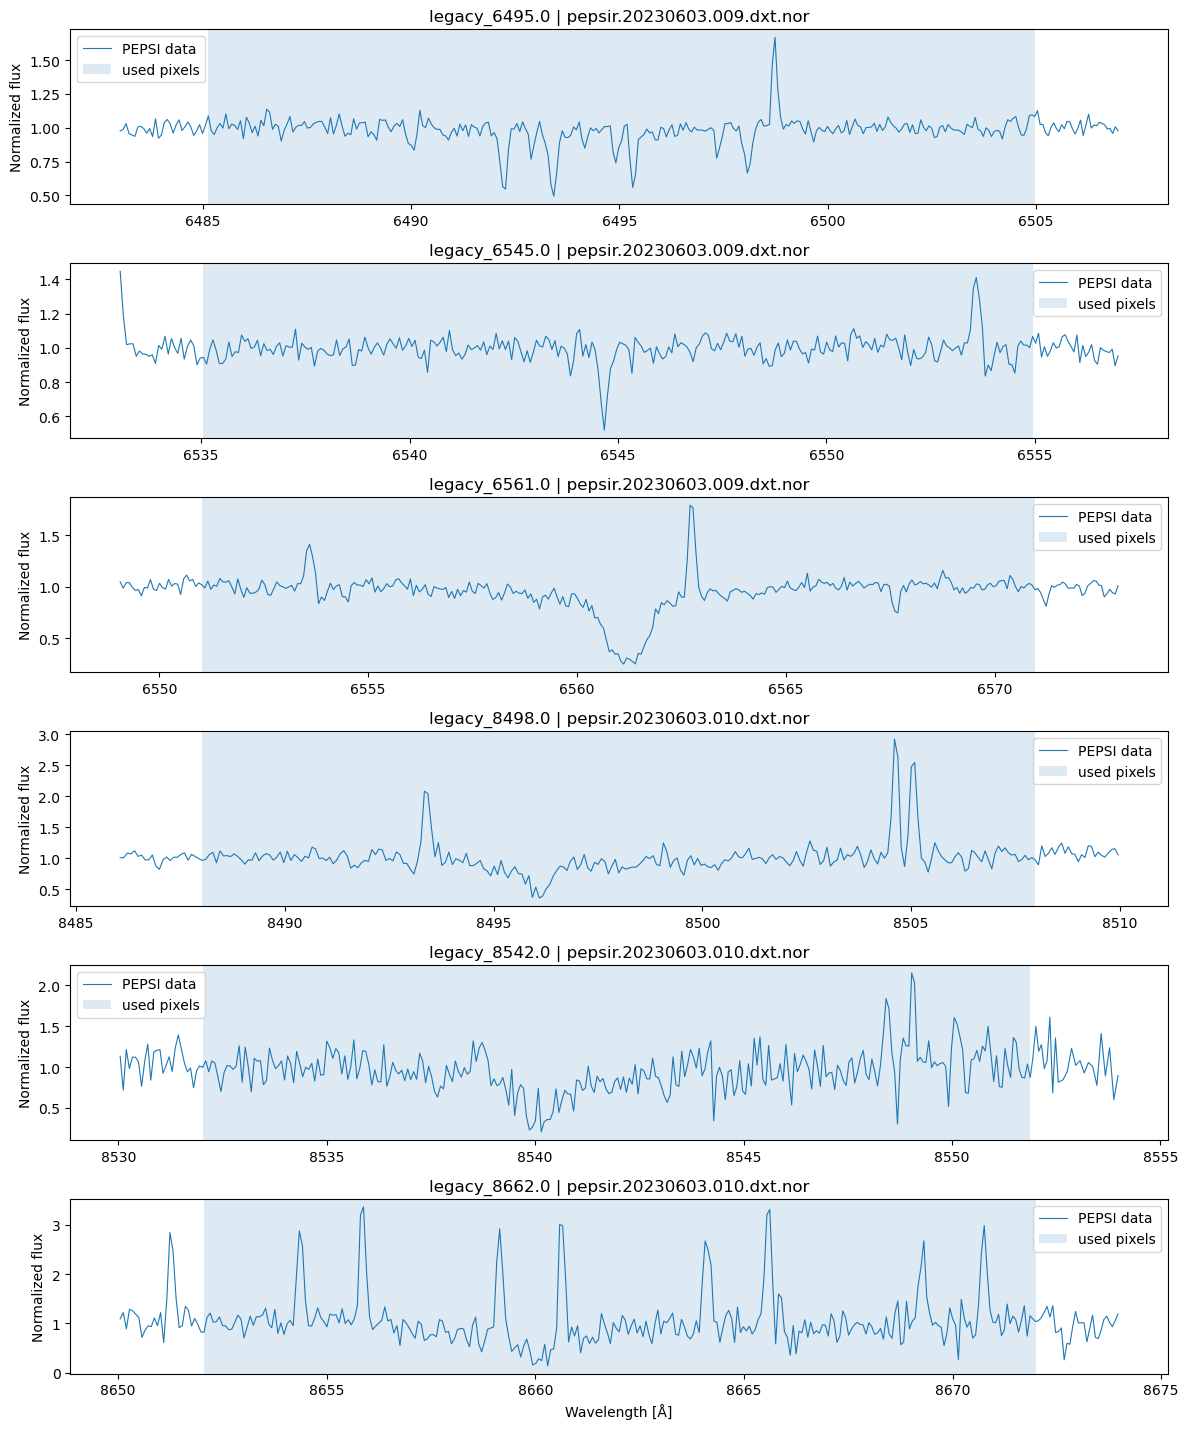

In [10]:
# Plot the PEPSI legacy line-window segments before fitting.

nseg = len(collection)
fig, axes = plt.subplots(nseg, 1, figsize=(12, 2.4 * nseg), sharex=False)

if nseg == 1:
    axes = [axes]

for ax, seg in zip(axes, collection.segments):
    ax.plot(seg.wave, seg.flux, lw=0.8, label="PEPSI data")

    fit_mask = np.asarray(seg.mask, dtype=bool)
    if np.any(fit_mask):
        ax.axvspan(
            float(np.nanmin(seg.wave[fit_mask])),
            float(np.nanmax(seg.wave[fit_mask])),
            alpha=0.15,
            label="used pixels",
        )

    ax.set_title(
        f"{seg.name} | {Path(seg.meta.get('source_file', '')).name}"
    )
    ax.set_ylabel("Normalized flux")
    ax.legend(loc="best")

axes[-1].set_xlabel("Wavelength [Å]")
plt.tight_layout()
plt.show()

## Prepare the PHOENIX model grid and cache

The next step builds the PHOENIX interpolation grid needed by the PEPSI line-window collection.

For speed, this validation uses the same restricted “fast” grid as the PEPSI smoke-test preset. This is enough to test the workflow and should recover the same stable solution basin as the script.

The cache grid is built from stable support windows rather than the final masked pixels. This avoids unnecessary cache rebuilds when the telluric mask or flux mask changes.

In [11]:
# Set up the PHOENIX library and the reduced validation grid.

phoenix_lib = PhoenixLibrary(phoenix_dir, verbose=True)

teff_avail, feh_avail, logg_avail = phoenix_lib.available_axes()

# Same reduced grid used by the pepsi_legacy_red_fast smoke-test preset.
teff_grid_req = pick_grid_range(teff_avail, 5000.0, 6000.0)
feh_grid_req = pick_grid_range(feh_avail, -1.5, 0.5)
logg_grid_req = pick_grid_range(logg_avail, 2.5, 4.0)

teff_grid_fit, feh_grid_fit, logg_grid_fit = phoenix_lib.complete_subgrid(
    teff_grid_req,
    feh_grid_req,
    logg_grid_req,
)

print("Teff grid:", teff_grid_fit)
print("[Fe/H] grid:", feh_grid_fit)
print("logg grid:", logg_grid_fit)

Teff grid: [5000. 5100. 5200. 5300. 5400. 5500. 5600. 5700. 5800. 5900. 6000.]
[Fe/H] grid: [-1.5 -1.  -0.5 -0.   0.5]
logg grid: [2.5 3.  3.5 4. ]


In [12]:
# Build or load the PHOENIX cache for the PEPSI legacy support windows.

cache_support_segments = make_pepsi_legacy_cache_support_segments(
    input_segments=input_segments,
    window_defs_air=window_defs_air,
    window_pad_A=window_pad_A,
)

cache_path = "/tmp/spyctres_pepsi_legacy_linefit_validation_air_fast_cache.npz"

model_wave_grid, model_wave_medium = ensure_phoenix_native_interpolator_for_segments(
    segments=cache_support_segments,
    phoenix_lib=phoenix_lib,
    teff_grid=teff_grid_fit,
    feh_grid=feh_grid_fit,
    logg_grid=logg_grid_fit,
    cache_path=cache_path,
    model_margin_A=20.0,
)

print("Model wave medium:", model_wave_medium)
print("Model grid size:", len(model_wave_grid))
print("Model wavelength range:", float(model_wave_grid[0]), float(model_wave_grid[-1]))
print("Cache path:", cache_path)

Loaded PHOENIX cache from /tmp/spyctres_pepsi_legacy_linefit_validation_air_fast_cache.npz
Model wave medium: air
Model grid size: 223155
Model wavelength range: 6463.023844076922 8693.962027611222
Cache path: /tmp/spyctres_pepsi_legacy_linefit_validation_air_fast_cache.npz


## Define the PEPSI legacy objective

The fit uses one shared parameter vector:

`Teff, [Fe/H], logg, RV, log10(error scale)`

For each trial parameter set, the notebook evaluates the PHOENIX model on all six PEPSI line-window segments, normalizes each local model window with the PEPSI legacy `model / max(model)` comparison, and sums the likelihood over the `SpectrumCollection`.

This objective is kept visible in the notebook so the validation logic is transparent, while the reusable model-evaluation and likelihood terms come from `Spyctres.recipes`.

In [13]:
# Shared PEPSI validation settings.

rv_bary_values = []
for seg in input_segments:
    ssbvel_mps = seg.meta.get("ssbvel_mps")
    if ssbvel_mps is not None:
        rv_bary_values.append(1.0e-3 * float(ssbvel_mps))

rv_bary_kms = float(np.nanmedian(rv_bary_values)) if rv_bary_values else 0.0

R_values = [
    float(seg.meta["resolution_R"])
    for seg in input_segments
    if seg.meta.get("resolution_R") is not None
]
R = float(np.nanmedian(R_values)) if len(R_values) else None

model_margin_A = 20.0

print("Barycentric correction from SSBVEL [km/s]:", rv_bary_kms)
print("Resolving power R:", R)

Barycentric correction from SSBVEL [km/s]: -23.205791
Resolving power R: 50000.0


In [14]:
def pepsi_legacy_objective(x):
    """
    Negative log-likelihood for the PEPSI legacy line-window validation.

    Parameters
    ----------
    x : sequence
        (Teff, [Fe/H], logg, RV, log10_error_scale)

    Returns
    -------
    float
        Summed weighted negative log-likelihood over the SpectrumCollection.
    """
    teff, feh, logg, rv, log_scale = map(float, x)

    try:
        models = evaluate_pepsi_legacy_max_models(
            phoenix_lib=phoenix_lib,
            segments=collection.segments,
            model_wave_grid=model_wave_grid,
            model_wave_medium=model_wave_medium,
            teff=teff,
            feh=feh,
            logg=logg,
            rv_kms=rv,
            rv_bary_kms=rv_bary_kms,
            R=R,
            model_margin_A=model_margin_A,
        )
    except Exception:
        return 1.0e100

    total = 0.0
    n_total = 0

    for seg, weight, model in zip(collection.segments, collection.weights, models):
        val, n, _model_norm, _used = pepsi_legacy_max_likelihood_terms(
            seg,
            model,
            log_err_scale=log_scale,
        )

        if not np.isfinite(val):
            return 1.0e100

        total += float(weight) * float(val)
        n_total += int(n)

    if n_total == 0:
        return 1.0e100

    return total

## Run the fast validation fit

We now run the same fast validation problem used by the PEPSI smoke-test preset.

The optimizer is seeded with a coarse RV scan. This avoids convergence to a poor local minimum in RV space. The bounds are intentionally restricted for this validation run, so the notebook remains fast and reproducible.

In [15]:
# Fast validation bounds and initial guess.

lo = np.array(
    [
        np.min(teff_grid_fit),
        np.min(feh_grid_fit),
        np.min(logg_grid_fit),
        -125.0,
        -2.0,
    ],
    dtype=float,
)

hi = np.array(
    [
        np.max(teff_grid_fit),
        np.max(feh_grid_fit),
        np.max(logg_grid_fit),
        25.0,
        1.0,
    ],
    dtype=float,
)

x0 = np.array(
    [
        5500.0,   # Teff
        -1.0,    # [Fe/H]
        3.0,     # logg
        -50.0,   # RV [km/s]
        0.0,     # log10 error scale
    ],
    dtype=float,
)

x0 = np.minimum(np.maximum(x0, lo), hi)

print("Initial guess:", x0)
print("Lower bounds :", lo)
print("Upper bounds :", hi)

Initial guess: [ 5.5e+03 -1.0e+00  3.0e+00 -5.0e+01  0.0e+00]
Lower bounds : [ 5.00e+03 -1.50e+00  2.50e+00 -1.25e+02 -2.00e+00]
Upper bounds : [6.0e+03 5.0e-01 4.0e+00 2.5e+01 1.0e+00]


In [16]:
# Coarse RV seed scan at the initial atmospheric parameters.

rv_grid = np.linspace(lo[3], hi[3], 41)
rv_scan_rows = []

for rv in rv_grid:
    xt = x0.copy()
    xt[3] = rv
    val = pepsi_legacy_objective(xt)
    rv_scan_rows.append({"rv_kms": float(rv), "nll": float(val)})

best_rv_row = min(rv_scan_rows, key=lambda row: row["nll"])
x0[3] = best_rv_row["rv_kms"]

print("Best coarse RV seed:", x0[3])
print_table(
    rv_scan_rows[::5],
    columns=["rv_kms", "nll"],
    float_formats={"rv_kms": ".1f", "nll": ".2f"},
)

Best coarse RV seed: -50.0
rv_kms | nll      
-------+----------
-125.0 | 299170.94
-106.2 | 255022.41
-87.5  | 209067.50
-68.8  | 138995.96
-50.0  | 43625.00 
-31.2  | 141226.01
-12.5  | 212849.89
6.2    | 244333.67
25.0   | 287539.95


In [17]:
# Run the bounded optimizer from the RV-seeded starting point.

fit_result = minimize(
    pepsi_legacy_objective,
    x0,
    method="L-BFGS-B",
    bounds=list(zip(lo, hi)),
    options={
        "maxiter": 50,
        "ftol": 1e-8,
    },
)

teff_best, feh_best, logg_best, rv_best, log_scale_best = map(float, fit_result.x)

print("Optimization success:", bool(fit_result.success))
print("Message:", fit_result.message)
print("Best-fit parameters:")
print("  Teff   =", teff_best)
print("  [Fe/H] =", feh_best)
print("  logg   =", logg_best)
print("  RV     =", rv_best)
print("  log10 error scale =", log_scale_best)
print("  error scale =", 10.0 ** log_scale_best)
print("  nll    =", float(fit_result.fun))

Optimization success: True
Message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Best-fit parameters:
  Teff   = 5333.285857735095
  [Fe/H] = -0.9203130341272878
  logg   = 2.6408618910326394
  RV     = -49.04829979212609
  log10 error scale = 0.7641990129436873
  error scale = 5.8103061045498645
  nll    = -2942.3086878737317


## Reconstruct the best-fit line-window models

We now evaluate the best-fit PHOENIX model on each PEPSI line-window segment, apply the same local `model / max(model)` normalization, and compute a final chi-square summary.

The reduced chi-square is computed after applying the fitted error-scale factor. This is useful as a consistency diagnostic, but the fitted error scale should also be reported because it absorbs unmodelled residual structure and underestimated formal errors.

In [18]:
# Reconstruct best-fit models and compute final residual statistics.

best_models_raw = evaluate_pepsi_legacy_max_models(
    phoenix_lib=phoenix_lib,
    segments=collection.segments,
    model_wave_grid=model_wave_grid,
    model_wave_medium=model_wave_medium,
    teff=teff_best,
    feh=feh_best,
    logg=logg_best,
    rv_kms=rv_best,
    rv_bary_kms=rv_bary_kms,
    R=R,
    model_margin_A=model_margin_A,
)

model_norm_list = []
used_masks = []
segment_rows = []

chi2 = 0.0
npts = 0

for seg, weight, model in zip(collection.segments, collection.weights, best_models_raw):
    nll_i, n_i, model_norm_i, used_i = pepsi_legacy_max_likelihood_terms(
        seg,
        model,
        log_err_scale=log_scale_best,
    )

    err_scaled = np.asarray(seg.err, dtype=float)[used_i] * (10.0 ** log_scale_best)
    resid_scaled = (
        np.asarray(seg.flux, dtype=float)[used_i] - model_norm_i[used_i]
    ) / err_scaled

    chi2_i = float(np.sum(resid_scaled * resid_scaled))
    chi2 += float(weight) * chi2_i
    npts += int(n_i)

    model_norm_list.append(model_norm_i)
    used_masks.append(used_i)

    segment_rows.append(
        {
            "segment": seg.name,
            "source": Path(seg.meta.get("source_file", "")).name,
            "n_fit": int(n_i),
            "weight": float(weight),
            "chi2": chi2_i,
            "chi2_per_pix": chi2_i / max(1, int(n_i)),
        }
    )

dof = max(1, npts - 5)
chi2_red = chi2 / dof

print("Global fit summary")
print("------------------")
print("Teff   =", teff_best)
print("[Fe/H] =", feh_best)
print("logg   =", logg_best)
print("RV     =", rv_best)
print("log10 error scale =", log_scale_best)
print("error scale =", 10.0 ** log_scale_best)
print("chi2   =", chi2)
print("dof    =", dof)
print("chi2_red =", chi2_red)

print("\nPer-segment residual summary")
print_table(
    segment_rows,
    columns=["segment", "source", "n_fit", "weight", "chi2", "chi2_per_pix"],
    float_formats={
        "weight": ".2f",
        "chi2": ".2f",
        "chi2_per_pix": ".3f",
    },
)

Global fit summary
------------------
Teff   = 5333.285857735095
[Fe/H] = -0.9203130341272878
logg   = 2.6408618910326394
RV     = -49.04829979212609
log10 error scale = 0.7641990129436873
error scale = 5.8103061045498645
chi2   = 1436.999045428659
dof    = 1432
chi2_red = 1.0034909535116334

Per-segment residual summary
segment       | source                      | n_fit | weight | chi2   | chi2_per_pix
--------------+-----------------------------+-------+--------+--------+-------------
legacy_6495.0 | pepsir.20230603.009.dxt.nor | 283   | 1.00   | 247.92 | 0.876       
legacy_6545.0 | pepsir.20230603.009.dxt.nor | 259   | 1.00   | 235.45 | 0.909       
legacy_6561.0 | pepsir.20230603.009.dxt.nor | 276   | 1.00   | 381.30 | 1.382       
legacy_8498.0 | pepsir.20230603.010.dxt.nor | 202   | 1.00   | 85.99  | 0.426       
legacy_8542.0 | pepsir.20230603.010.dxt.nor | 218   | 1.00   | 219.36 | 1.006       
legacy_8662.0 | pepsir.20230603.010.dxt.nor | 199   | 1.00   | 266.98 | 1.342     

## Paper-style line-window comparison plot

The compact full-spectrum diagnostic plot is not ideal for this validation because the PEPSI windows are widely separated in wavelength. For inspection, it is clearer to plot each fitted line window in its own panel, similar to the PEPSI figure in the paper.

The plot below shows the normalized PEPSI data and the locally normalized PHOENIX model in each selected window.

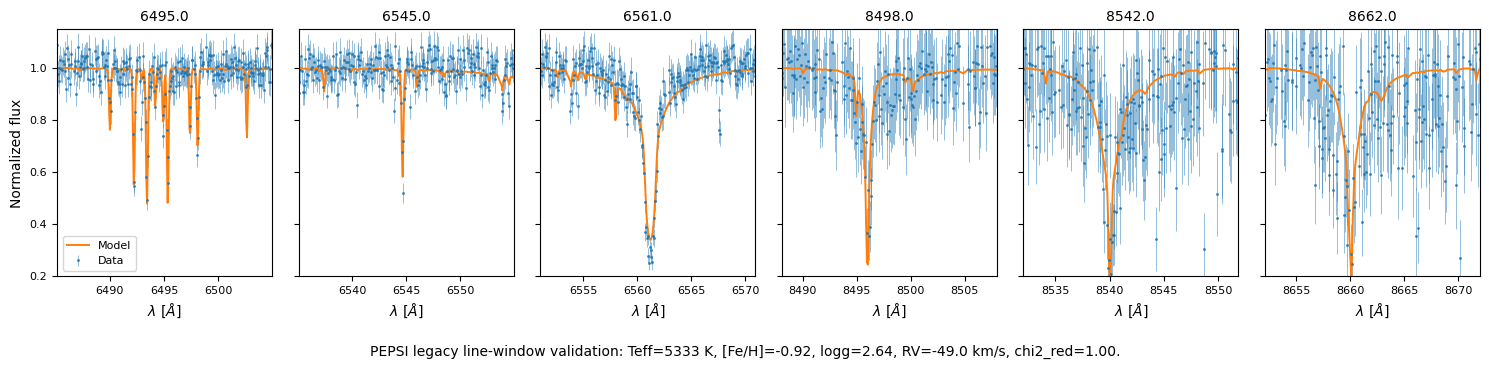

In [19]:
# Paper-style multi-panel plot for the PEPSI legacy windows.

nseg = len(collection.segments)

fig, axes = plt.subplots(
    1,
    nseg,
    figsize=(2.5 * nseg, 3.4),
    sharey=True,
)

if nseg == 1:
    axes = [axes]

for i, (ax, seg, model_norm, used) in enumerate(
    zip(axes, collection.segments, model_norm_list, used_masks)
):
    wave = np.asarray(seg.wave, dtype=float)
    flux = np.asarray(seg.flux, dtype=float)
    err_scaled = np.asarray(seg.err, dtype=float) * (10.0 ** log_scale_best)
    used = np.asarray(used, dtype=bool)

    # Plot only the pixels used in the likelihood.
    w = wave[used]
    f = flux[used]
    e = err_scaled[used]
    m = np.asarray(model_norm, dtype=float)[used]

    order = np.argsort(w)
    w = w[order]
    f = f[order]
    e = e[order]
    m = m[order]

    ax.errorbar(
        w,
        f,
        yerr=e,
        fmt=".",
        ms=2.3,
        lw=0.45,
        alpha=0.75,
        label="Data" if i == 0 else None,
    )
    ax.plot(
        w,
        m,
        lw=1.4,
        label="Model" if i == 0 else None,
    )

    ax.set_xlim(float(np.nanmin(w)), float(np.nanmax(w)))
    ax.set_ylim(0.2, 1.15)

    label = seg.name.replace("legacy_", "")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel(r"$\lambda$ [$\AA$]")
    ax.tick_params(axis="both", labelsize=8)

    if i == 0:
        ax.set_ylabel("Normalized flux")
        ax.legend(loc="lower left", fontsize=8, frameon=True)

caption = (
    "PEPSI legacy line-window validation: "
    f"Teff={teff_best:.0f} K, [Fe/H]={feh_best:.2f}, "
    f"logg={logg_best:.2f}, RV={rv_best:.1f} km/s, "
    f"chi2_red={chi2_red:.2f}."
)

fig.text(0.5, -0.03, caption, ha="center", va="top", fontsize=10)
plt.tight_layout()
plt.show()

## Interpretation

This notebook reproduces the same fast PEPSI legacy line-window validation result as the `pepsi_fit_smoketest.py` preset.

The important checks are:

- the red PEPSI spectra are read into `SpectrumSegment` objects;
- the selected local line windows are converted into a `SpectrumCollection`;
- telluric masking and flux filtering reproduce the same fitted pixel counts as the smoke test;
- the PHOENIX model is evaluated through the native-grid forward model with instrumental broadening;
- the optimizer recovers the same stable RV basin near `-49 km/s`;
- the final reduced chi-square is close to one after applying the fitted error-scale factor.

This notebook is not intended to be the public classification workflow. The public multi-segment classification example should remain methodologically uniform and use the generic `fit_phoenix_full_spectrum()` path.

Here, the purpose is narrower: to show that the shared Spyctres infrastructure can also support the PEPSI legacy line-window workflow in a modular way. The PEPSI-specific part is the local window normalization and likelihood, while the spectrum containers, PHOENIX backend, wavelength handling, broadening, and cache logic are shared with the rest of the PHOENIX fitting framework.

The fitted parameters should therefore be interpreted as a validation result for this line-window setup, not as a final source-parameter determination.

In [20]:
print("PEPSI legacy line-window validation")
print("=" * 40)
print("Collection:", collection.name)
print("Segments:", list(collection.names))
print("Weights:", collection.weights.tolist())
print()
print("Best-fit parameters")
print("-------------------")
print(f"Teff   = {teff_best:.1f} K")
print(f"[Fe/H] = {feh_best:.3f}")
print(f"logg   = {logg_best:.3f}")
print(f"RV     = {rv_best:.3f} km/s")
print(f"log10 error scale = {log_scale_best:.3f}")
print(f"error scale       = {10.0 ** log_scale_best:.3f}")
print()
print("Fit quality")
print("-----------")
print(f"nll      = {float(fit_result.fun):.3f}")
print(f"chi2     = {chi2:.3f}")
print(f"dof      = {dof}")
print(f"chi2_red = {chi2_red:.4f}")

PEPSI legacy line-window validation
Collection: pepsi_legacy_windows
Segments: ['legacy_6495.0', 'legacy_6545.0', 'legacy_6561.0', 'legacy_8498.0', 'legacy_8542.0', 'legacy_8662.0']
Weights: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

Best-fit parameters
-------------------
Teff   = 5333.3 K
[Fe/H] = -0.920
logg   = 2.641
RV     = -49.048 km/s
log10 error scale = 0.764
error scale       = 5.810

Fit quality
-----------
nll      = -2942.309
chi2     = 1436.999
dof      = 1432
chi2_red = 1.0035
